## Figure 11: Comparsion between reference and predicted designs from a single testing sample

Single-device view of each device, reference and predicted, labeling their distinct design parameter values

In [1]:
from matplotlib.patches import FancyBboxPatch

def caption_box(ax, text):
    # wide, short box in axes coordinates
    box = FancyBboxPatch(
        (0.08, -0.20),   # x, y
        0.84, 0.10,      # width, height
        transform=ax.transAxes,
        boxstyle="round,pad=0.02",
        facecolor="white",
        edgecolor="#4E758D",
        linewidth=1.2,
        clip_on=False
    )
    ax.add_patch(box)

wrote Figure11.png
wrote Figure11.pdf


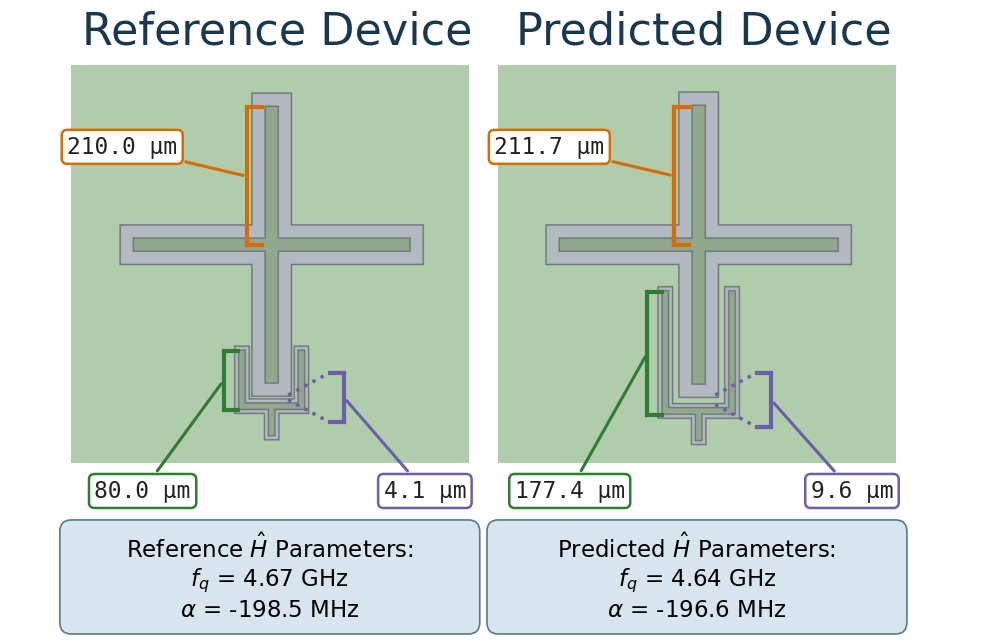

In [2]:
%matplotlib inline
import io
from pathlib import Path

import fitz  # PyMuPDF
import matplotlib

#matplotlib.use("Agg")

import matplotlib.pyplot as plt
from PIL import Image

# Source files are resolved from either the repository root or figures/paper.
source_dir_candidates = [
    Path("source_materials"),
    Path("figures/paper/source_materials"),
]

for candidate in source_dir_candidates:
    if (candidate / "ref_design_76.pdf").exists():
        SOURCE_DIR = candidate
        break
else:
    raise FileNotFoundError("Could not find source_materials/ref_design_76.pdf")

if SOURCE_DIR.name == "source_materials":
    EXPORT_DIR = SOURCE_DIR.parent / "manuscript_exports"
else:
    EXPORT_DIR = Path("figures/paper/manuscript_exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Crop and rotate the rendered Qiskit/Quantum Metal PDF view.
crop_rect = fitz.Rect(190, 50, 470, 330)
dpi = 180
rotation_angle = 90

with fitz.open(SOURCE_DIR / "ref_design_76.pdf") as doc:
    # alpha=False composites on white; avoids transparent regions rendering black
    pix = doc[0].get_pixmap(clip=crop_rect, dpi=dpi, alpha=False)
ref_transmon = Image.open(io.BytesIO(pix.tobytes("png"))).rotate(rotation_angle, expand=True)

with fitz.open(SOURCE_DIR / "pred_design_76.pdf") as doc:
    # alpha=False composites on white; avoids transparent regions rendering black
    pix = doc[0].get_pixmap(clip=crop_rect, dpi=dpi, alpha=False)
pred_transmon = Image.open(io.BytesIO(pix.tobytes("png"))).rotate(rotation_angle, expand=True)

# Original label coordinates were tuned on a 584 px square crop. Scale them
# so changing the render DPI keeps the annotations aligned to the geometry.
base_width_px = 584
scale = ref_transmon.size[0] / base_width_px
s = lambda value: value * scale

colors = {
    "cross_length": "#D96C00",
    "claw_length": "#2E7D32",
    "ground_spacing": "#6D5EA8",
}

# Font sizes are intentionally larger than manuscript body text because this
# figure is usually scaled down to one Overleaf column.
TITLE_FONT_SIZE = 16.0*2
LABEL_FONT_SIZE = 16.5
BRACKET_LINEWIDTH = 3.0
CALLOUT_LINEWIDTH = 2.2
DOTTED_LINEWIDTH = 2.5
BBOX_LINEWIDTH = 1.8

ref_fq = "4.67 GHz"
ref_alpha = "-198.5 MHz"
pred_fq = "4.64 GHz"
pred_alpha = "-196.6 MHz"


ref_cross_length = "210.0 µm"
ref_claw_length = "80.0 µm"
ref_ground_spacing = "4.1 µm"

pred_cross_length = "211.7 µm"
pred_claw_length = "177.4 µm"
pred_ground_spacing = "9.6 µm"


fig, ax = plt.subplots(1,2,figsize=(6.2*2, 5.2*2),gridspec_kw={"wspace": -0.20})
#plt.subplots_adjust(wspace=0,hspace=0)
fig.patch.set_facecolor("white")
ax[0].set_facecolor("white")
ax[0].imshow(ref_transmon, zorder=1)
ax[0].set_xlim(s(-90), s(695))
ax[0].set_ylim(s(665), s(-20))
ax[0].axis("off")
ax[0].set_title("Reference Device", color="#17384F", fontsize=TITLE_FONT_SIZE, pad=7)

ax[1].set_facecolor("white")
ax[1].imshow(pred_transmon, zorder=1)
ax[1].set_xlim(s(-90), s(695))
ax[1].set_ylim(s(665), s(-20))
ax[1].axis("off")
ax[1].set_title("Predicted Device", color="#17384F", fontsize=TITLE_FONT_SIZE, pad=7)


def draw_vertical_bracket(ax,x, y1, y2, color):
    tick = s(21)
    sx = s(x)
    sy1 = s(y1)
    sy2 = s(y2)
    ax.plot([sx - tick, sx], [sy1, sy1], color=color, lw=BRACKET_LINEWIDTH, zorder=4)
    ax.plot([sx - tick, sx], [sy2, sy2], color=color, lw=BRACKET_LINEWIDTH, zorder=4)
    ax.plot([sx - tick, sx - tick], [sy1, sy2], color=color, lw=BRACKET_LINEWIDTH, zorder=4)
    return sx - tick, (sy1 + sy2) / 2


def draw_callout(ax,text, xy, xytext, color):
    ax.annotate(
        text,
        xy=xy,
        xytext=(s(xytext[0]), s(xytext[1])),
        textcoords="data",
        ha="center",
        va="center",
        fontsize=LABEL_FONT_SIZE,
        family="monospace",
        color="#222222",
        bbox={
            "boxstyle": "round,pad=0.24",
            "facecolor": "white",
            "edgecolor": color,
            "linewidth": BBOX_LINEWIDTH,
        },
        arrowprops={
            "arrowstyle": "-",
            "color": color,
            "lw": CALLOUT_LINEWIDTH,
            "shrinkA": 2,
            "shrinkB": 3,
        },
        zorder=10,
    )


''' REFERENCE DEVICE ''' 
# design_options.cross_length
cross_xy = draw_vertical_bracket(ax[0],280, 60, 263, colors["cross_length"])
draw_callout(ax[0],ref_cross_length, cross_xy, (75, 118), colors["cross_length"])

# design_options.connection_pads.readout.claw_length
claw_xy = draw_vertical_bracket(ax[0],245, 418, 505, colors["claw_length"])
draw_callout(ax[0],
    ref_claw_length,
    claw_xy,
    (105, 624),
    colors["claw_length"],
)

# design_options.connection_pads.readout.ground_spacing
x1, x2 = 319, 380
top_y1, top_y2 = 483, 450
bottom_y1 = 490
bottom_y2 = bottom_y1 + (top_y1 - top_y2)
tick = s(21)
gap_color = colors["ground_spacing"]
ax[0].plot([s(x1), s(x2)], [s(top_y1), s(top_y2)], linestyle="dotted", color=gap_color, lw=DOTTED_LINEWIDTH, zorder=5)
ax[0].plot([s(x1), s(x2)], [s(bottom_y1), s(bottom_y2)], linestyle="dotted", color=gap_color, lw=DOTTED_LINEWIDTH, zorder=5)
ax[0].plot([s(x2) + tick, s(x2)], [s(top_y2), s(top_y2)], color=gap_color, lw=BRACKET_LINEWIDTH, zorder=5)
ax[0].plot([s(x2) + tick, s(x2)], [s(bottom_y2), s(bottom_y2)], color=gap_color, lw=BRACKET_LINEWIDTH, zorder=5)
ax[0].plot([s(x2) + tick, s(x2) + tick], [s(top_y2), s(bottom_y2)], color=gap_color, lw=BRACKET_LINEWIDTH, zorder=5)
draw_callout(ax[0],
    ref_ground_spacing,
    (s(x2) + tick, (s(top_y2) + s(bottom_y2)) / 2),
    (520, 624),
    gap_color,
)

''' PREDICTED DEVICE ''' 
# design_options.cross_length
cross_xy = draw_vertical_bracket(ax[1],280, 59, 263, colors["cross_length"])
draw_callout(ax[1],pred_cross_length, cross_xy, (75, 118), colors["cross_length"])

# design_options.connection_pads.readout.claw_length
claw_xy = draw_vertical_bracket(ax[1],240, 331, 512, colors["claw_length"])
draw_callout(ax[1],
    pred_claw_length,
    claw_xy,
    (105, 624),
    colors["claw_length"],
)

# design_options.connection_pads.readout.ground_spacing
x1, x2 = 319, 380
top_y1, top_y2 = 483, 450
bottom_y1 = 497
bottom_y2 = bottom_y1 + (top_y1 - top_y2)
tick = s(21)
gap_color = colors["ground_spacing"]
ax[1].plot([s(x1), s(x2)], [s(top_y1), s(top_y2)], linestyle="dotted", color=gap_color, lw=DOTTED_LINEWIDTH, zorder=5)
ax[1].plot([s(x1), s(x2)], [s(bottom_y1), s(bottom_y2)], linestyle="dotted", color=gap_color, lw=DOTTED_LINEWIDTH, zorder=5)
ax[1].plot([s(x2) + tick, s(x2)], [s(top_y2), s(top_y2)], color=gap_color, lw=BRACKET_LINEWIDTH, zorder=5)
ax[1].plot([s(x2) + tick, s(x2)], [s(bottom_y2), s(bottom_y2)], color=gap_color, lw=BRACKET_LINEWIDTH, zorder=5)
ax[1].plot([s(x2) + tick, s(x2) + tick], [s(top_y2), s(bottom_y2)], color=gap_color, lw=BRACKET_LINEWIDTH, zorder=5)
draw_callout(ax[1],
    pred_ground_spacing,
    (s(x2) + tick, (s(top_y2) + s(bottom_y2)) / 2),
    (520, 624),
    gap_color,
)

#fig.tight_layout(pad=0)


''' HAMILTONIAN BOXES ''' 
''' REFERENCE '''
img_width, img_height = ref_transmon.size
box_width = img_width
box_height = 0.23 * img_height
box_x = 0
box_y = img_height + 0.17 * img_height
box_pad = 20

text_x = box_x + box_width / 2
text_y = box_y + box_height / 2

box = FancyBboxPatch(
    (box_x, box_y),
    box_width,
    box_height,
    boxstyle=f"round,pad={box_pad}",
    facecolor="#D6E5EE",
    edgecolor="#567A90",
    linewidth=1.2,
    clip_on=False,
    zorder=1
)

ax[0].add_patch(box)


ref_label = (
    r"Reference $\hat{H}$ Parameters:"
    + "\n"
    + rf"$f_q$ = {ref_fq}"
    + "\n"
    + rf"$\alpha$ = {ref_alpha}"
)

ax[0].text(
    text_x,
    text_y,
    ref_label,
    #transform=ax[0].transAxes,
    ha="center",
    va="center",
    fontsize=LABEL_FONT_SIZE,
    color="black",
    clip_on=False,
    zorder=5
)

''' PREDICTED '''
img_width, img_height = ref_transmon.size
box_width = img_width
box_height = 0.23 * img_height
box_x = 0
box_y = img_height + 0.17 * img_height
box_pad = 20

text_x = box_x + box_width / 2
text_y = box_y + box_height / 2

box = FancyBboxPatch(
    (box_x, box_y),
    box_width,
    box_height,
    boxstyle=f"round,pad={box_pad}",
    facecolor="#D6E5EE",
    edgecolor="#567A90",
    linewidth=1.2,
    clip_on=False,
    zorder=1
)

ax[1].add_patch(box)


pred_label = (
    r"Predicted $\hat{H}$ Parameters:"
    + "\n"
    + rf"$f_q$ = {pred_fq}"
    + "\n"
    + rf"$\alpha$ = {pred_alpha}"
)

ax[1].text(
    text_x,
    text_y,
    pred_label,
    #transform=ax[0].transAxes,
    ha="center",
    va="center",
    fontsize=LABEL_FONT_SIZE,
    color="black",
    clip_on=False,
    zorder=5
)

png_path = EXPORT_DIR / "figure11_predicted_vs_reference_design_comparsion_v2.png"
pdf_path = EXPORT_DIR / "figure11_predicted_vs_reference_design_comparsion_v2.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight", pad_inches=0.04, facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.04, facecolor="white")
print(f"wrote {png_path}")
print(f"wrote {pdf_path}")
fig
